In [1]:
import sys
sys.path.insert(0, '../../')

import math
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.animation as animation
from deepssfp import ssfp, recon

In [2]:
# Experiment parameters
T1, T2 = 1.2, .035
TR, alpha = 5e-3, np.deg2rad(30)
TE = TR / 2.0
BetaMax = 2 * np.pi
beta = np.linspace(-BetaMax, BetaMax, 100)
f = beta / TR / (2 * np.pi)
npcs = 4
pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)

# Simulate acquisition of phase-cycles for a single voxel
M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=f)
print(M.shape)

(100, 4)


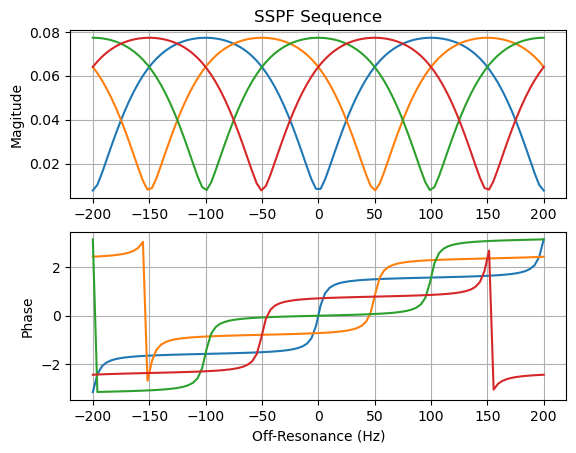

In [3]:
plt.subplot(211)
plt.plot(f, np.absolute(M))
plt.ylabel('Magitude')
plt.title('SSPF Sequence')
plt.grid(True)

plt.subplot(212)
plt.plot(f, np.angle(M))
plt.xlabel('Off-Resonance (Hz)')
plt.ylabel('Phase')
plt.grid(True)
plt.show()

In [21]:
M2 = M**2
out0 = np.sqrt(np.mean(M2, axis=1))
out1 = recon.gs_recon(M, pc_axis=1, second_pass=True)
print(out0.shape, out1.shape)


(100,) (1, 100)


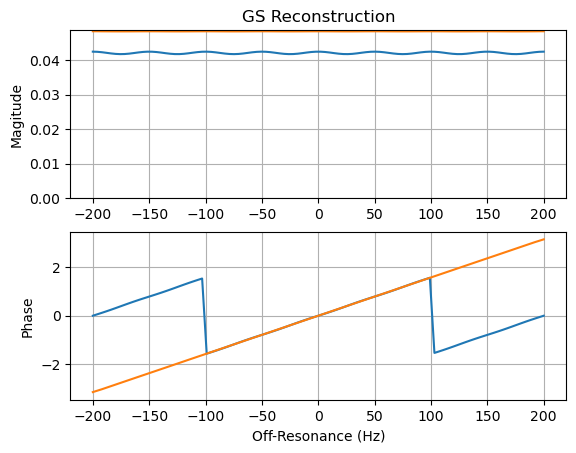

In [26]:
plt.subplot(211)
plt.plot(f, np.absolute(out0))
plt.plot(f, np.absolute(out1[0]))
plt.ylabel('Magitude')
plt.title('GS Reconstruction')
plt.gca().set_ylim(bottom=0)
plt.grid(True)

plt.subplot(212)
plt.plot(f, np.angle(out0))
plt.plot(f, np.angle(out1[0]))
plt.xlabel('Off-Resonance (Hz)')
plt.ylabel('Phase')
plt.grid(True)
plt.show()